# Climate Stripes

This notebook demonstrates how to calculate a climatological mean of a long time-series of data.

In [9]:
from earthkit import data as ekd
from earthkit import transforms as ekt
from earthkit import plots as ekp
from earthkit.transforms._tools import earthkit_remote_test_data_file

# Get some demonstration ERA5 data, this could be any url or path to an ERA5 grib or netCDF file.
remote_era5_file = earthkit_remote_test_data_file("ERA5-Reading-2m-temperature-1940-2025.nc")
era5_data = ekd.from_source("url", remote_era5_file)
era5_data.describe()

path,/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/earthkit-data-edwardcomyn-platt/url-026ad38a941e4653283b7732cbbdeebe3b2e03395d9ac98a5f4d28d925354841.nc
size,8.6 MiB
types,"xarray, pandas, fieldlist, numpy, array"


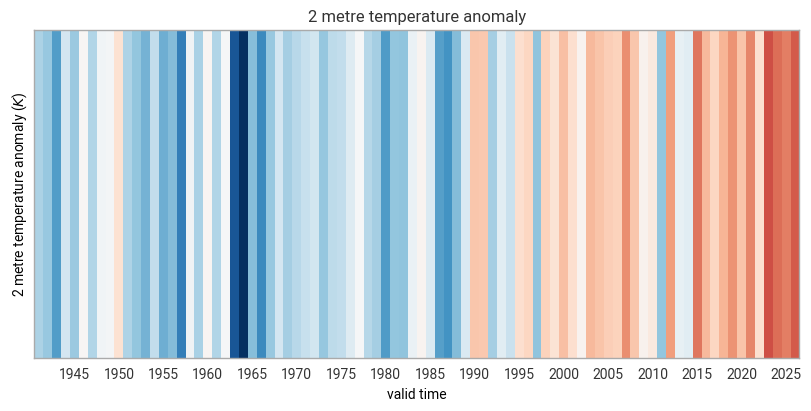

In [10]:
annual_anomaly = ekt.climatology.auto_anomaly(
    era5_data, climatology_range=("1981", "2010"), frequency="year"
)

# Plot the climate stripes with earthkit-plots.
ekp.timeseries.stripes(annual_anomaly, cmap="RdBu_r").xticks(frequency="5Y")